# In Major League Baseball, what's more important to winning? An elite offense or an elite pitching staff? Let's find out

#### Import statements

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### Load datasets

In [103]:
hitting_df = pd.read_csv("hittingData.csv")
pitching_df = pd.read_csv("pitchingData.csv")

#### Demonstrate data

In [104]:
hitting_df.head()

,Season,Team,PA,HR,R,RBI,SB,ISO,BABIP,AVG,OBP,SLG,wOBA,wRAA,wRC+,EV,BsR,Off,Def,WAR
0,1894,Orioles,5413,33,1171,976.0,324.0,0.140,0.353,0.343,0.418,0.483,0.417,210.2,114,NaN,6.9,156.3,70.1,35.2
1,1894,Phillies,5520,40,1143,981.0,273.0,0.128,0.361,0.349,0.414,0.476,0.413,190.2,114,NaN,-5.1,144.4,17.9,29.4
2,1894,Beaneaters,5593,103,1220,1043.0,241.0,0.153,0.335,0.331,0.401,0.484,0.406,151.2,105,NaN,-8.6,50.3,16.7,23.7
3,1927,Yankees,6222,158,976,908.0,90.0,0.181,0.324,0.307,0.384,0.488,0.400,266.7,126,NaN,-14.2,203.7,76.2,49.3
4,1895,Phillies,5689,61,1068,930.0,276.0,0.119,0.340,0.330,0.394,0.450,0.397,182.2,117,NaN,-0.2,162.5,4.7,31.3


In [105]:
pitching_df.head()

,Season,Team,W,L,SV,IP,R,ER,H/9,K/9,...,HR/9,WHIP,BABIP,EV,ERA,FIP,xFIP,RAR,RA9-WAR,WAR
0,1876,Brown Stockings,45,19,0,577.0,229,78,7.36,1.61,...,0.05,0.89,0.235,NaN,1.22,2.15,NaN,41.0,15.7,3.4
1,1884,Grays,84,28,2,1036.1,388,185,7.16,5.55,...,0.23,0.96,0.259,NaN,1.61,2.86,NaN,152.8,34.4,13.3
2,1875,Dark Blues,54,28,0,771.0,343,139,8.24,0.19,...,0.05,0.94,0.245,NaN,1.62,2.46,NaN,114.7,25.0,9.6
3,1880,Grays,52,32,2,799.0,299,146,7.47,3.22,...,0.08,0.89,0.250,NaN,1.64,2.12,NaN,82.5,18.5,8.2
4,1882,Red Stockings,55,25,0,721.1,268,132,7.60,2.06,...,0.09,1.02,0.244,NaN,1.65,2.95,NaN,67.0,22.8,6.0


## Data Cleaning and Aggregation

In [106]:
#Change the duplicate column names first between the two datasets
hitting_df.rename(columns={'R': 'RS'}, inplace=True) #replace 'Runs' with 'Runs Scored'
hitting_df.rename(columns={'WAR': 'bWAR'}, inplace=True) #replace 'WAR' with 'Batting War'

pitching_df.rename(columns={'R': 'RA'}, inplace=True)#replace 'Runs' with 'RUns Allowed'
pitching_df.rename(columns={'BABIP': 'oppBABIP'}, inplace=True) #replace 'batting average - balls in play' with opponent's batting average on balls in play
pitching_df.rename(columns={'EV': 'oppEV'}, inplace=True) # replace 'exit velo' with 'opponent's exit velo'
pitching_df.rename(columns={'WAR': 'pWAR'}, inplace=True) #repalce 'WAR' with 'pitching WAR'

print(pitching_df.columns)
print(hitting_df.columns)

Index(['Season', 'Team', 'W', 'L', 'SV', 'IP', 'RA', 'ER', 'H/9', 'K/9',
       'BB/9', 'HR/9', 'WHIP', 'oppBABIP', 'oppEV', 'ERA', 'FIP', 'xFIP',
       'RAR', 'RA9-WAR', 'pWAR'],
      dtype='object')
Index(['Season', 'Team', 'PA', 'HR', 'RS', 'RBI', 'SB', 'ISO', 'BABIP', 'AVG',
       'OBP', 'SLG', 'wOBA', 'wRAA', 'wRC+', 'EV', 'BsR', 'Off', 'Def',
       'bWAR'],
      dtype='object')


In [107]:
#merge datasets
baseball_df = pd.merge(pitching_df, hitting_df, on=['Season', 'Team'])
baseball_df.head()

,Season,Team,W,L,SV,IP,RA,ER,H/9,K/9,...,OBP,SLG,wOBA,wRAA,wRC+,EV,BsR,Off,Def,bWAR
0,1876,Brown Stockings,45,19,0,577.0,229,78,7.36,1.61,...,0.276,0.313,0.274,-6.4,106,NaN,0.0,21.7,61.0,16.1
1,1884,Grays,84,28,2,1036.1,388,185,7.16,5.55,...,0.293,0.315,0.283,15.1,99,NaN,0.0,-7.3,84.7,22.1
2,1875,Dark Blues,54,28,0,771.0,343,139,8.24,0.19,...,0.267,0.310,0.264,8.9,96,NaN,1.3,-19.7,31.4,12.1
3,1880,Grays,52,32,2,799.0,299,146,7.47,3.22,...,0.268,0.313,0.265,-5.1,101,NaN,0.0,2.5,59.4,17.7
4,1882,Red Stockings,55,25,0,721.1,268,132,7.60,2.06,...,0.289,0.332,0.283,17.3,107,NaN,0.0,30.6,25.6,16.6


In [108]:
#create new columns
baseball_df['GP'] = baseball_df['W'] + baseball_df['L'] #games played
baseball_df['UER'] = baseball_df['RA'] - baseball_df['ER'] #unearned runs
baseball_df['wPCT'] = round((baseball_df['W']/baseball_df['GP']), 3) #winning percentage
baseball_df.columns

Index(['Season', 'Team', 'W', 'L', 'SV', 'IP', 'RA', 'ER', 'H/9', 'K/9',
       'BB/9', 'HR/9', 'WHIP', 'oppBABIP', 'oppEV', 'ERA', 'FIP', 'xFIP',
       'RAR', 'RA9-WAR', 'pWAR', 'PA', 'HR', 'RS', 'RBI', 'SB', 'ISO', 'BABIP',
       'AVG', 'OBP', 'SLG', 'wOBA', 'wRAA', 'wRC+', 'EV', 'BsR', 'Off', 'Def',
       'bWAR', 'GP', 'UER', 'wPCT'],
      dtype='object')

In [109]:
# check data types
print(baseball_df.dtypes)

Season        int64
Team         object
W             int64
L             int64
SV            int64
IP          float64
RA            int64
ER            int64
H/9         float64
K/9         float64
BB/9        float64
HR/9        float64
WHIP        float64
oppBABIP    float64
oppEV       float64
ERA         float64
FIP         float64
xFIP        float64
RAR         float64
RA9-WAR     float64
pWAR        float64
PA            int64
HR            int64
RS            int64
RBI         float64
SB          float64
ISO         float64
BABIP       float64
AVG         float64
OBP         float64
SLG         float64
wOBA        float64
wRAA        float64
wRC+          int64
EV          float64
BsR         float64
Off         float64
Def         float64
bWAR        float64
GP            int64
UER           int64
wPCT        float64
dtype: object


In [110]:
# number of missing values
print('Missing values: ', baseball_df.isnull().sum())

Missing values:  Season         0
Team           0
W              0
L              0
SV             0
IP             0
RA             0
ER             0
H/9            0
K/9            0
BB/9           0
HR/9           0
WHIP           0
oppBABIP       0
oppEV       2793
ERA            0
FIP            0
xFIP        2403
RAR            0
RA9-WAR        0
pWAR           0
PA             0
HR             0
RS             0
RBI           15
SB           129
ISO            0
BABIP        296
AVG            0
OBP            0
SLG            0
wOBA           0
wRAA           0
wRC+           0
EV          2793
BsR            0
Off            0
Def            0
bWAR           0
GP             0
UER            0
wPCT           0
dtype: int64


In [111]:
missing_df = baseball_df.isnull().mean().to_frame(name='% Missing Data')
missing_df['% Missing Data'] = missing_df['% Missing Data'].apply(lambda x: f"{x*100:.2f}%")
missing_vars = missing_df[missing_df['% Missing Data'] != '0.00%']
print(missing_vars.sort_values('% Missing Data', ascending=False))

      % Missing Data
oppEV         94.90%
EV            94.90%
xFIP          81.65%
SB             4.38%
BABIP         10.06%
RBI            0.51%


In [112]:
# we drop EV and oppEV because of how scarce the data is, not enough information
baseball_df.drop(['EV', 'oppEV'], axis=1, inplace=True)
# replace missing values with some predicted values using a linear regression model
no_obj = baseball_df.select_dtypes(exclude='object')
imputer = IterativeImputer(random_state=1).fit_transform(no_obj)
impute_df = pd.DataFrame(data=imputer, columns=no_obj.columns)
baseball_df = pd.concat([baseball_df['Team'], impute_df], axis=1)
#no more missing data, let's double check to make sure
print('Missing Data:', baseball_df.isnull().sum())

Missing Data: Team        0
Season      0
W           0
L           0
SV          0
IP          0
RA          0
ER          0
H/9         0
K/9         0
BB/9        0
HR/9        0
WHIP        0
oppBABIP    0
ERA         0
FIP         0
xFIP        0
RAR         0
RA9-WAR     0
pWAR        0
PA          0
HR          0
RS          0
RBI         0
SB          0
ISO         0
BABIP       0
AVG         0
OBP         0
SLG         0
wOBA        0
wRAA        0
wRC+        0
BsR         0
Off         0
Def         0
bWAR        0
GP          0
UER         0
wPCT        0
dtype: int64


In [113]:
# number of duplicates
print('Number of Duplicates: {}'.format(baseball_df.duplicated().sum()))

Number of Duplicates: 0


In [114]:
#I filtered the best features for this study, read why I chose each stat here: https://github.com/zachpeetz/hitting-vs.-pitching
# keep only the necessary variables for this study
vars_keep = ['Season', 'Team', 'wPCT', 'wOBA', 'wRC+', 'FIP', 'WHIP']
baseball_df = baseball_df[vars_keep]
#here is our data now, before we do analysis
baseball_df.head()

,Season,Team,wPCT,wOBA,wRC+,FIP,WHIP
0,1876.0,Brown Stockings,0.703,0.274,106.0,2.15,0.89
1,1884.0,Grays,0.750,0.283,99.0,2.86,0.96
2,1875.0,Dark Blues,0.659,0.264,96.0,2.46,0.94
3,1880.0,Grays,0.619,0.265,101.0,2.12,0.89
4,1882.0,Red Stockings,0.688,0.283,107.0,2.95,1.02


In [115]:
#Check for Multicollinearity, are any features highly correlated?
X = baseball_df[['wOBA', 'wRC+', 'FIP', 'WHIP']]
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

  Feature         VIF
0    wOBA  347.795845
1    wRC+  148.043523
2     FIP   72.631042
3    WHIP  153.649063


#### wRC+ and wOBA are highly correlated hitting statistics, meaning we can remove one. Same for WHIP and FIP on the pitching side

In [116]:
baseball_df = baseball_df.drop(columns = ['WHIP', 'wRC+']) #I chose these stats to remove per domain knowledge, I explain more on github
baseball_df

,Season,Team,wPCT,wOBA,FIP
0,1876.0,Brown Stockings,0.703,0.274,2.15
1,1884.0,Grays,0.750,0.283,2.86
2,1875.0,Dark Blues,0.659,0.264,2.46
3,1880.0,Grays,0.619,0.265,2.12
4,1882.0,Red Stockings,0.688,0.283,2.95
...,...,...,...,...,...
2938,1996.0,Tigers,0.327,0.325,5.83
2939,1872.0,Olympics,0.222,0.256,3.67
2940,1930.0,Phillies,0.338,0.370,5.54
2941,1872.0,Nationals,0.000,0.234,3.82


In [117]:
# See multicollinearity now after the columns get dropped
X = baseball_df[['wOBA', 'FIP']]  # Updated features
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


  Feature        VIF
0    wOBA  42.482613
1     FIP  42.482613


## Data Analysis

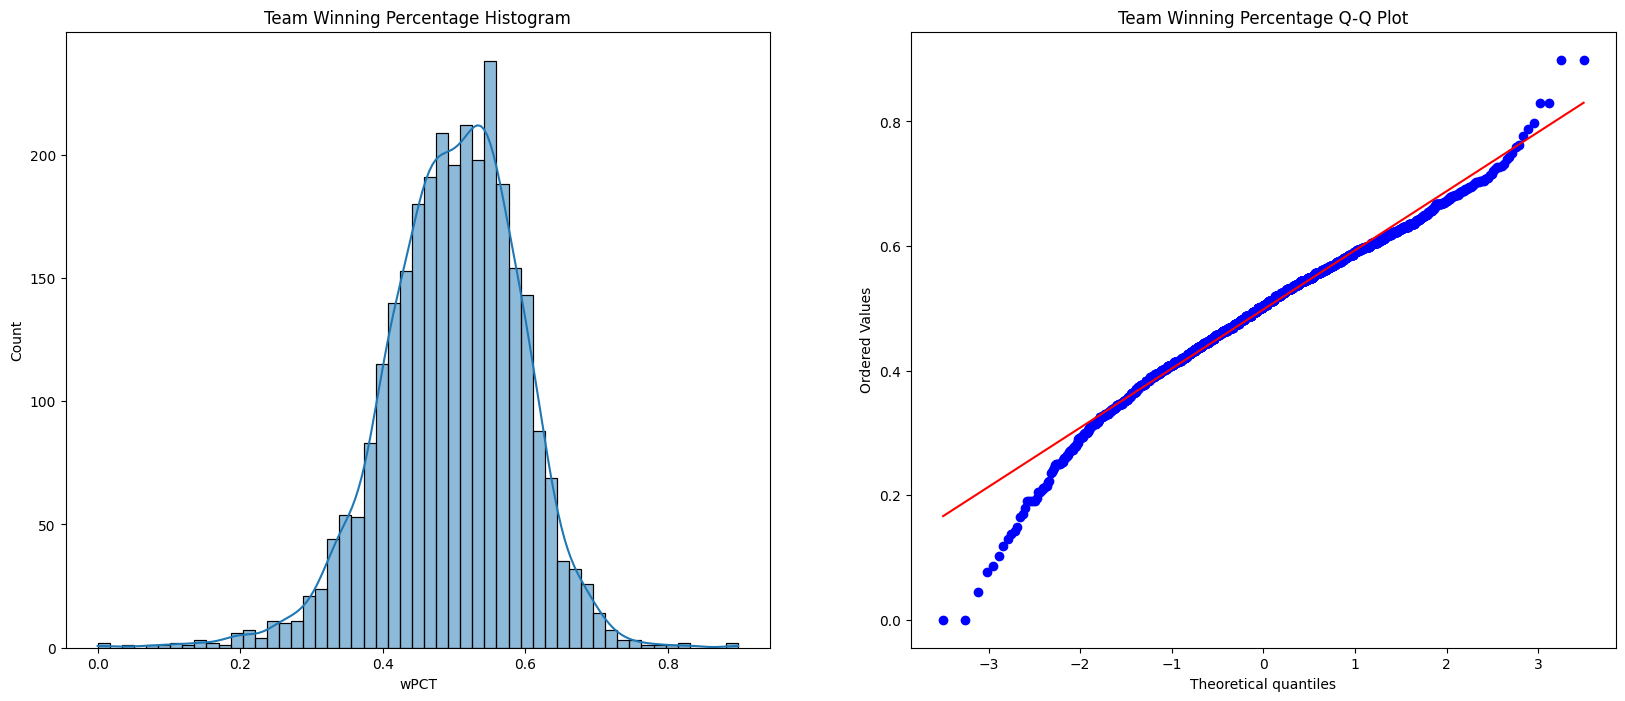

In [118]:
# normality
# 'wPCT' normality
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(baseball_df['wPCT'], kde=True, ax=axes[0])
axes[0].set_title('Team Winning Percentage Histogram')

stats.probplot(baseball_df['wPCT'], plot=axes[1])
axes[1].set_title('Team Winning Percentage Q-Q Plot')

plt.show()

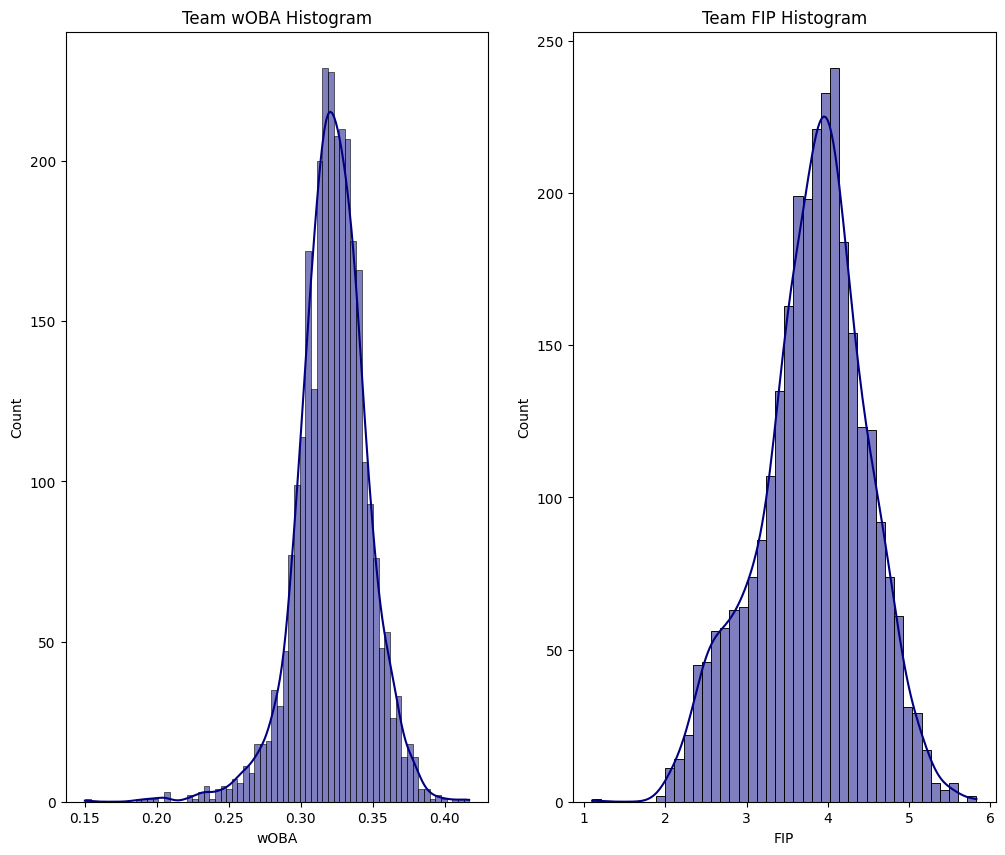

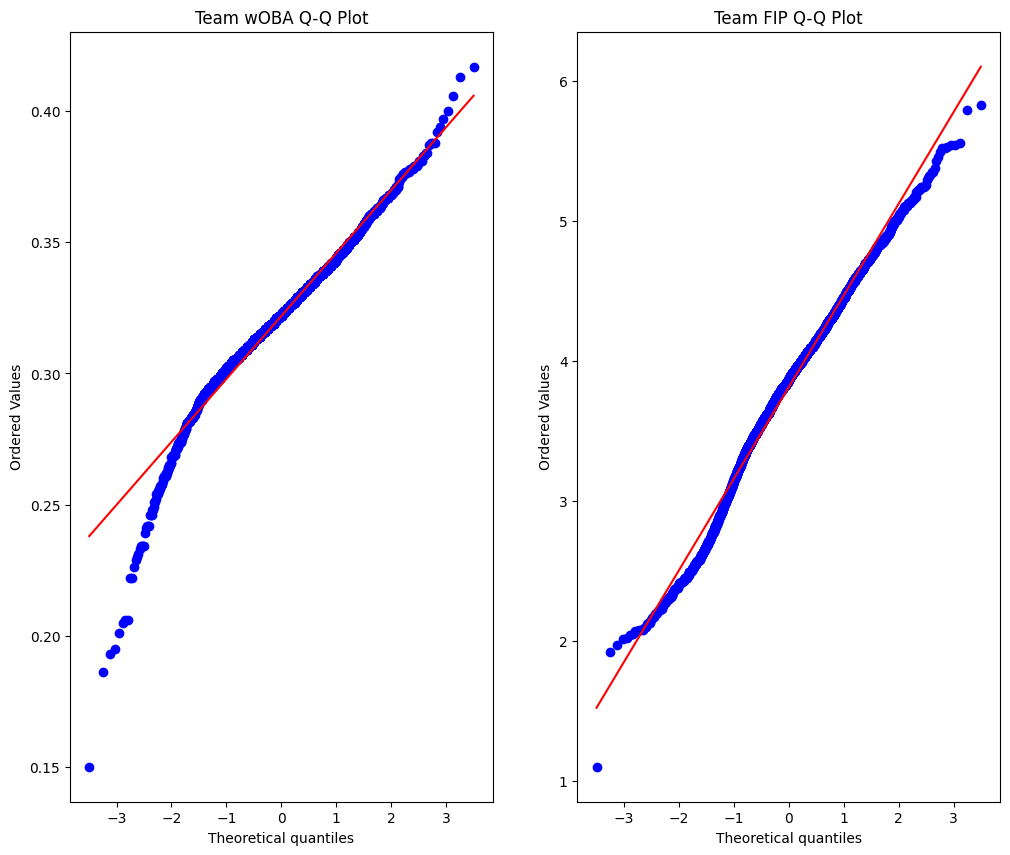

In [119]:
# independent variables normality
ind_vars = ['wOBA', 'FIP']

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

for col, ax in zip(ind_vars, axes.flatten()[:7]):
    sns.histplot(baseball_df[col], kde=True, color='navy', ax=ax)
    ax.set_title(f'Team {col} Histogram')

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

for col, ax in zip(ind_vars, axes.flatten()[:7]):
    stats.probplot(baseball_df[col], plot=ax)
    ax.set_title(f'Team {col} Q-Q Plot')

plt.show()

In [120]:
#descriptive summary
print(baseball_df.describe().to_string())
baseball_df.columns

            Season         wPCT         wOBA          FIP
count  2943.000000  2943.000000  2943.000000  2943.000000
mean   1957.147808     0.498109     0.321950     3.811617
std      42.767742     0.095611     0.024404     0.657699
min    1871.000000     0.000000     0.150000     1.100000
25%    1920.000000     0.440000     0.308500     3.430000
50%    1965.000000     0.504000     0.322000     3.870000
75%    1995.000000     0.562000     0.337000     4.240000
max    2019.000000     0.899000     0.417000     5.830000


Index(['Season', 'Team', 'wPCT', 'wOBA', 'FIP'], dtype='object')

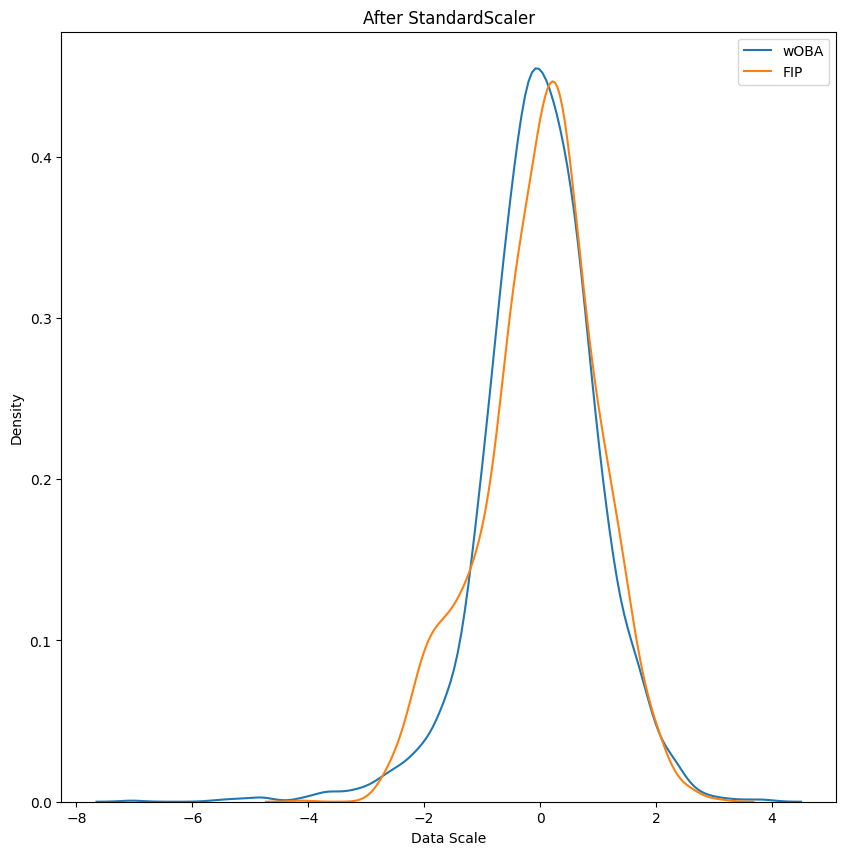

In [121]:
#as all the independent variables have different ranges, scale them to be safe
not_scale = ['Season', 'Team', 'wPCT']
for_scale = baseball_df.drop(not_scale, axis=1)
cols = list(for_scale.columns)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(for_scale)
scaled_df = pd.DataFrame(scaled_data, columns=cols)

scaled_df = pd.concat([baseball_df[not_scale], scaled_df], axis=1)

# KDE plot
fig, ax = plt.subplots(figsize=(10, 10))

for col in cols:
    sns.kdeplot(scaled_df[col], ax=ax, label=col)
    ax.set_title('After StandardScaler')
    ax.set_xlabel('Data Scale')
    plt.legend(loc=1)

plt.show()

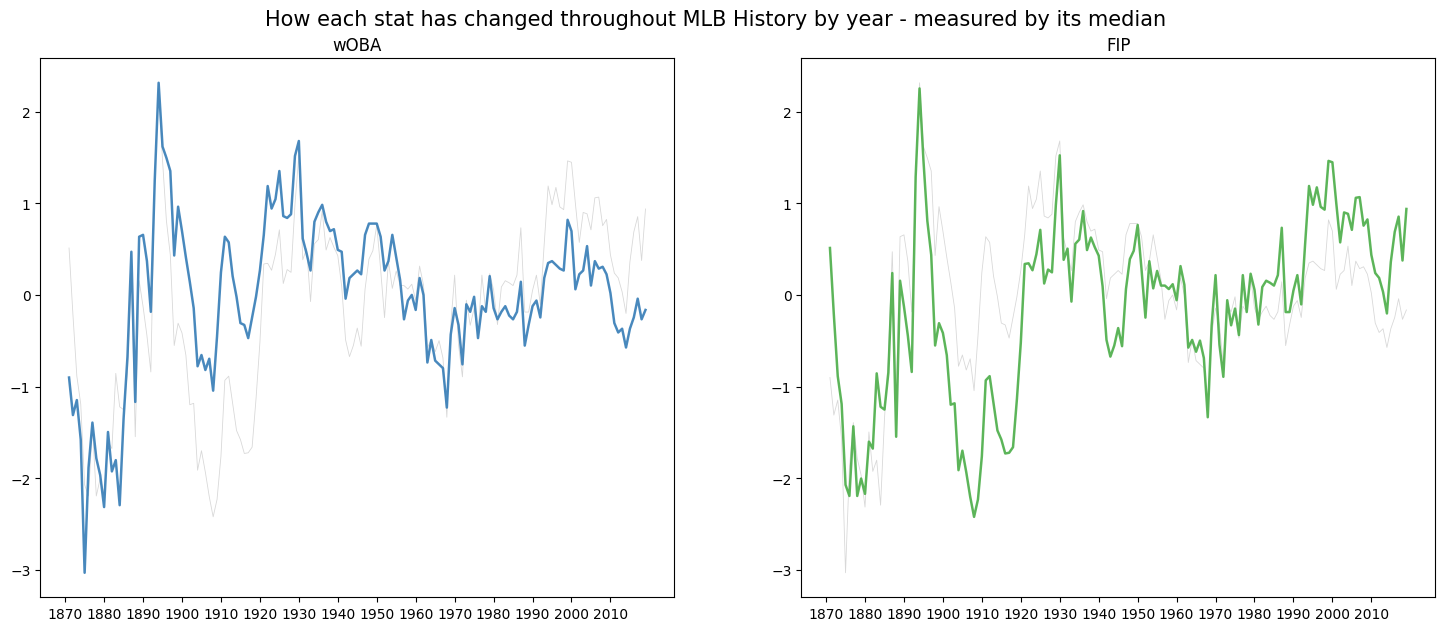

In [122]:
# Changes in median values of each stat throughout the MLB history
# note: scaled data is used for this analysis to accurately compare different metrics
season_df = scaled_df.groupby('Season')[ind_vars].median()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = plt.get_cmap('Set1')
num = 0

for col, ax in zip(season_df, axes.flatten()[:7]):
    num += 1
    for var in season_df:
        ax.plot(season_df[var], marker='', color='grey', linewidth=.6, alpha=.3)

    ax.plot(season_df[col], marker='', color=palette(num), linewidth=1.8, alpha=.9,
             label=col)

    ax.set_title(col, loc='center', fontsize=12, fontweight=0)
    ax.set_xticks(range(1870, 2020, 10))

plt.suptitle('How each stat has changed throughout MLB History by year - measured by its median',
             fontsize=15, fontweight=1, y=0.95)
plt.show()

In [123]:
# create year bins
bins = [1870, 1900, 1920, 1940, 1960, 1980, 2000, 2020]
labels = ['1871-1899', '1900-1919', '1920-1939', '1940-1959',
          '1960-1979', '1980-1999', '2000-2019']
data = [baseball_df, scaled_df]

for df in data:
    df['Era'] = pd.cut(df['Season'], bins, labels=labels,
                       include_lowest=True, right=False)
# changes in 'mean' and 'median' stats in different eras
era_grouped = baseball_df.groupby('Era', as_index=False)
era_grouped_stats = era_grouped[ind_vars].agg(['mean', 'median'])
print(era_grouped_stats.to_string())

         Era      wOBA               FIP       
                  mean  median      mean median
0  1871-1899  0.308300  0.3090  3.456336   3.42
1  1900-1919  0.316695  0.3160  2.824878   2.80
2  1920-1939  0.344181  0.3425  4.157094   4.12
3  1940-1959  0.330056  0.3305  3.861687   3.86
4  1960-1979  0.313083  0.3135  3.639257   3.63
5  1980-1999  0.323394  0.3220  4.085037   4.04
6  2000-2019  0.322848  0.3220  4.255167   4.24


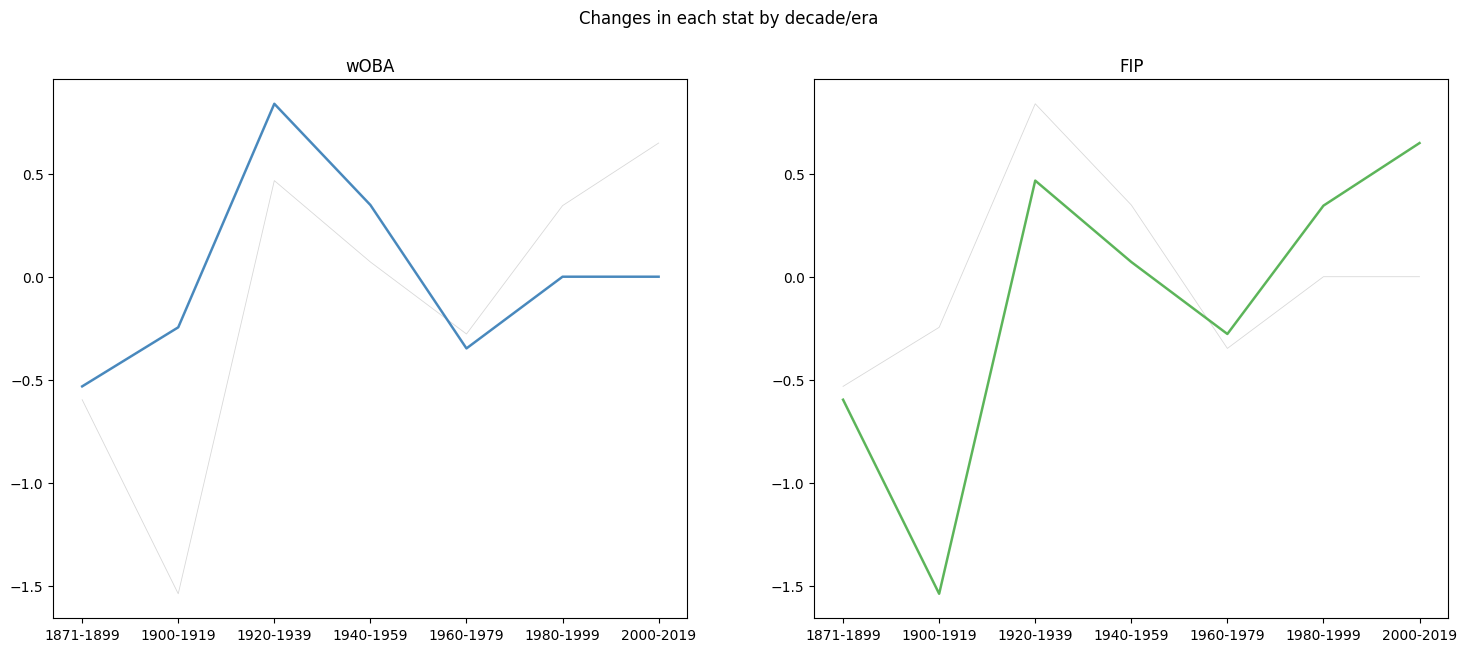

In [124]:
# Changes in median values of each stat throughout different eras
scaled_era_df = scaled_df.groupby('Era')
scaled_era_stats = scaled_era_df[ind_vars].median()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = plt.get_cmap('Set1')
num = 0

for col, ax in zip(ind_vars, axes.flatten()[:7]):
    num += 1
    for var in scaled_era_stats:
        ax.plot(scaled_era_stats[var], marker='', color='grey', linewidth=.6, alpha=.3)

    ax.plot(scaled_era_stats[col], marker='', color=palette(num), linewidth=1.8, alpha=.9)
    ax.set_title(col, loc='center', fontsize=12, fontweight=0)

plt.suptitle('Changes in each stat by decade/era')
plt.show()

In [125]:
#compare teams whose 'wPCT' is higher than 0.500 with teams whose 'wPCT' is less than 0.500
scaled_df['wPCT>500'] = np.where(scaled_df['wPCT'] >= 0.500, '> 0.500', '< 0.500')

wPCT_groups = scaled_df.groupby('wPCT>500')
wPCT_group_stats = wPCT_groups[ind_vars].median().reset_index()
print(wPCT_group_stats)

  wPCT>500      wOBA       FIP
0  < 0.500 -0.325807  0.316889
1  > 0.500  0.370913 -0.078495


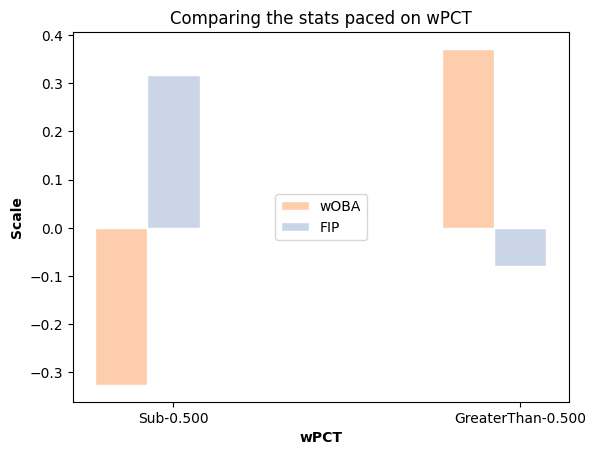

In [126]:
# grouped bar plot
barWidth = 0.15
wOBA = wPCT_groups['wOBA'].median()
FIP = wPCT_groups['FIP'].median()

category = [wOBA, FIP]

r1 = np.arange(len(wOBA))
r2 = [x + barWidth for x in r1]

rs = [r1, r2]

category_color = plt.get_cmap('Pastel2')
num = 0

for var, r, col in zip(category, rs, ind_vars):
    num += 1
    plt.bar(r, var, color=category_color(num), width=barWidth, edgecolor='white', label=col)

plt.title('Comparing the stats paced on wPCT')
plt.xlabel('wPCT', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(wOBA))], ['Sub-0.500', 'GreaterThan-0.500'])
plt.ylabel('Scale', fontweight='bold')
plt.legend(loc='center')
plt.show()


          Season      wPCT      wOBA       FIP
Season  1.000000  0.037242  0.108537  0.504813
wPCT    0.037242  1.000000  0.487481 -0.211140
wOBA    0.108537  0.487481  1.000000  0.430895
FIP     0.504813 -0.211140  0.430895  1.000000


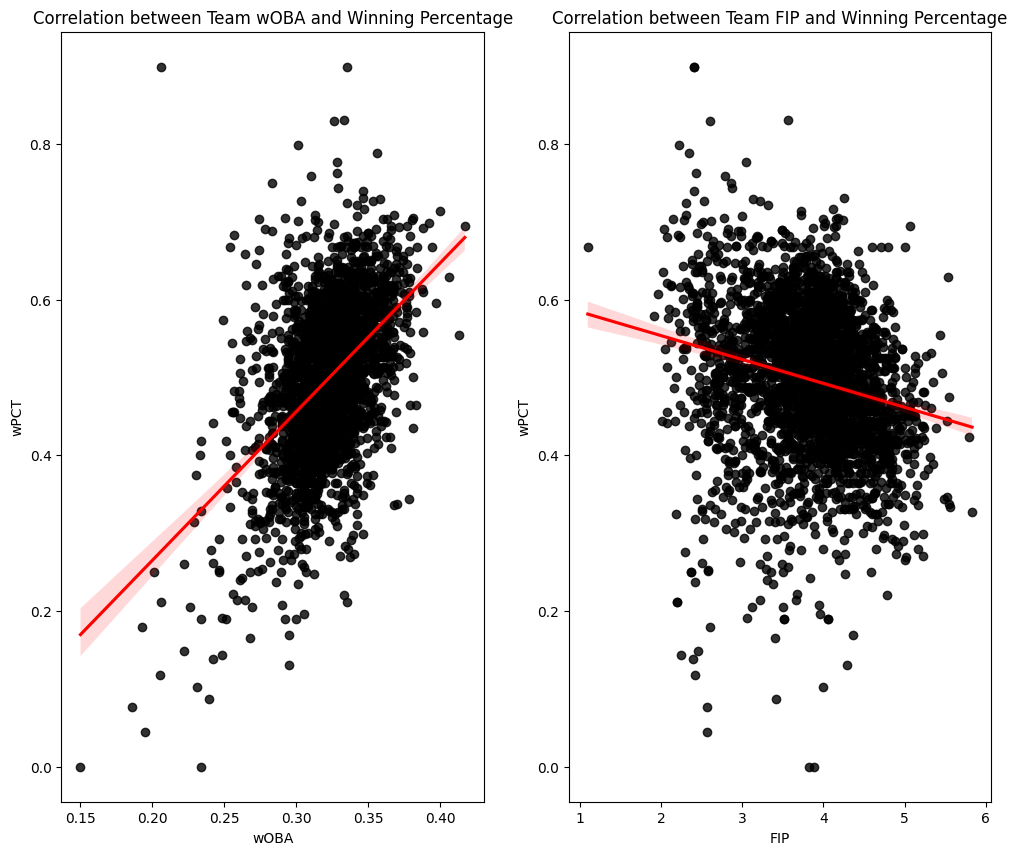

In [127]:
# correlation matrix
numeric_columns = baseball_df.select_dtypes(include=[np.number])

# Calculate correlation matrix for numeric columns only
corrMatrix = numeric_columns.corr()
print(corrMatrix.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# Assuming 'ind_vars' is a list of independent variables to plot
for col, ax in zip(ind_vars, axes.flatten()[:4]):  # Make sure the number of columns doesn't exceed 4
    sns.regplot(x=col, y='wPCT', data=baseball_df, scatter_kws={'color':'black'},
                line_kws={'color':'red'}, ax=ax)
    ax.set_title(f'Correlation between Team {col} and Winning Percentage')

plt.show()


### Random Forest Regression

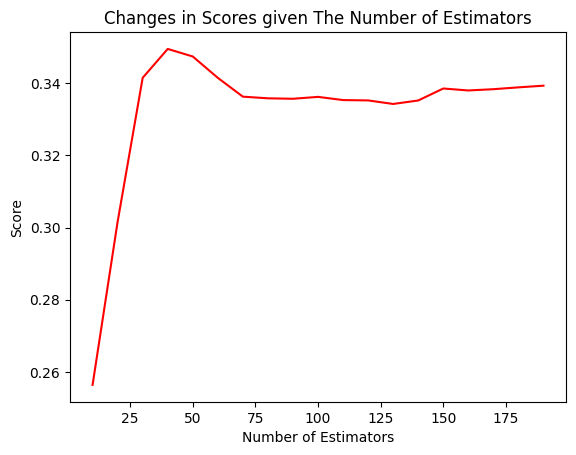

In [128]:
# find the best number of estimators for random forest regression
x = baseball_df.drop(columns=['Season', 'Team', 'wPCT', 'Era'], axis=1)
y = baseball_df['wPCT']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

model = RandomForestRegressor(n_jobs=-1, random_state=1)

n_estimators = np.arange(10, 200, 10)
scores = []

for n in n_estimators:
    model.set_params(n_estimators=n)
    model.fit(x_train, y_train)
    scores.append([n, model.score(x_test, y_test)])

scores_df = pd.DataFrame(scores, columns=['n Estimators', 'Score'])

fig, ax = plt.subplots()
sns.lineplot(x='n Estimators', y='Score', data=scores_df, color='red', ax=ax)
ax.set_title('Changes in Scores given The Number of Estimators')
ax.set_xlabel('Number of Estimators')
ax.set_ylabel('Score')
plt.show()

In [129]:
Nbest_estimators = scores_df[scores_df['Score'] == scores_df['Score'].max()]
print('Best Number of Estimators:', Nbest_estimators[['n Estimators', 'Score']])

Best Number of Estimators:    n Estimators     Score
3            40  0.349553


In [130]:
# random forest regression

Nbest_estimators = scores_df.loc[scores_df['Score'] == scores_df['Score'].max(), 'n Estimators'].item()
model = RandomForestRegressor(n_estimators=Nbest_estimators, n_jobs=-1, random_state=0)
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

score = model.score(x_test, y_test)
mse = metrics.mean_squared_error(y_test, y_predict)

print('Random Forest Regression:')
print(f'R-squared: {score}')
print(f'RMSE: {math.sqrt(mse)}')

# random forest feature importance
importance = model.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
print()
print('Random Forest Feature Importance:')
for i in sorted_idx:
    print(f'{x.columns[i]} Importance: {round(importance[i], 3)}')

Random Forest Regression:
R-squared: 0.3147432309060877
RMSE: 0.07508312082426985

Random Forest Feature Importance:
wOBA Importance: 0.506
FIP Importance: 0.494


## It seems that FIP is the more important feature after regression, let's see if that holds

### Let's now compare these stats across eras

In [131]:
eras = sorted(list(baseball_df['Era'].unique()))
importance_dict = {}

for era in eras:
    data = baseball_df[baseball_df['Era'] == era]
    x = data.drop(['Season', 'Team', 'wPCT', 'Era'], axis=1)
    y = data['wPCT']

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
    model = RandomForestRegressor(n_jobs=-1, random_state=1)
    model.fit(x_train, y_train)

    n_estimators = list(range(10, 200, 10))
    scores = []

    for n in n_estimators:
        model.set_params(n_estimators=n)
        model.fit(x_train, y_train)
        scores.append([n, model.score(x_test, y_test)])

    scores_df = pd.DataFrame(scores, columns=['n Estimators', 'Score'])
    Nbest_estimators = scores_df.loc[scores_df['Score'] == scores_df['Score'].max(), 'n Estimators'].item()

    model = RandomForestRegressor(n_estimators=Nbest_estimators, n_jobs=-1, random_state=0)
    model.fit(x_train, y_train)
    y_predict = model.predict(x_test)

    score = model.score(x_test, y_test)
    mse = metrics.mean_squared_error(y_test, y_predict)

    print(f'Random Forest Regression for {era}')
    print(f'R-squared: {score}')
    print(f'RMSE: {math.sqrt(mse)}')
    print()


    # random forest feature importance cross-era comparison
    importance = model.feature_importances_
    importance_dict[era] = list(np.round(importance, 3))
    sorted_indices = np.argsort(importance)[::-1]

    print(f'Random Forest Feature Importance for {era}')
    for i in sorted_indices:
        print(f'{x.columns[i]} Importance: {round(importance[i], 3)}')
    print()
    # K-fold cross validation
    cv_mse = cross_val_score(model, x, y, scoring='neg_mean_squared_error', cv=10)
    cv_rmse = np.sqrt(-1 * cv_mse)

    print(f'10-Fold Cross Validation for {era}')
    print(f'Mean RMSE: {cv_rmse.mean()}')


Random Forest Regression for 1871-1899
R-squared: 0.39470535649973204
RMSE: 0.13584228004930435

Random Forest Feature Importance for 1871-1899
wOBA Importance: 0.598
FIP Importance: 0.402

10-Fold Cross Validation for 1871-1899
Mean RMSE: 0.1277604958508714
Random Forest Regression for 1900-1919
R-squared: 0.530205308256003
RMSE: 0.06355188265918192

Random Forest Feature Importance for 1900-1919
wOBA Importance: 0.588
FIP Importance: 0.412

10-Fold Cross Validation for 1900-1919
Mean RMSE: 0.07391679555949109
Random Forest Regression for 1920-1939
R-squared: 0.5353521270413617
RMSE: 0.06281198619071698

Random Forest Feature Importance for 1920-1939
wOBA Importance: 0.591
FIP Importance: 0.409

10-Fold Cross Validation for 1920-1939
Mean RMSE: 0.06849712556797806
Random Forest Regression for 1940-1959
R-squared: 0.6445019174492933
RMSE: 0.05704193725961012

Random Forest Feature Importance for 1940-1959
wOBA Importance: 0.579
FIP Importance: 0.421

10-Fold Cross Validation for 1940-1

### Let's visual these feature importances

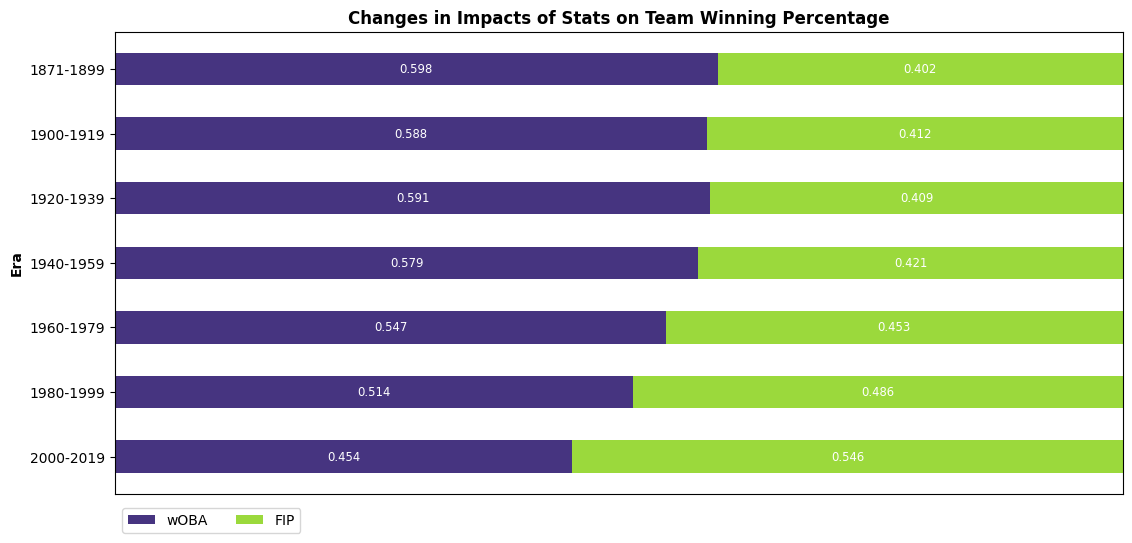

In [132]:
category_names = ind_vars
results = dict(sorted(importance_dict.items()))

def importance_score(results, category_names):
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    category_colors = plt.get_cmap('viridis')(np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        ax.barh(labels, widths, left=starts, height=0.5,
                label=colname, color=color)
        xcenters = starts + widths / 2

        r, g, b, _ = color
        text_color = 'white'
        for y, (x, c) in enumerate(zip(xcenters, widths)):
            ax.text(x, y, str(float(c)), ha='center', va='center',
                    color=text_color, fontsize='small')
    ax.set_title('Changes in Impacts of Stats on Team Winning Percentage',
                 fontweight='bold')
    ax.set_ylabel('Era', fontweight='bold')
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, -0.1),
              loc='lower left', fontsize='medium')

    return fig, ax

importance_score(results, category_names)
plt.show()

In [133]:
avg_wOBA_impact = sum([v[0] for v in results.values()]) / len(results)
avg_FIP_impact = sum([v[1] for v in results.values()]) / len(results)
print(f'Overall wOBA impact: {avg_wOBA_impact.round(3)}')
print(f'Overall FIP impact: {avg_FIP_impact.round(3)}')

Overall wOBA impact: 0.553
Overall FIP impact: 0.447


# Conclusion

##### Based on the feature importance scores, with wOBA (Weighted On-Base Average) at 0.553 and FIP (Fielding Independent Pitching) at 0.447, we can conclude that offense historically has a slightly stronger impact on a team's success (winning percentage) than pitching. The higher value of wOBA suggests that offensive metrics play a larger role in predicting a team's success. 

##### It’s important to note that both offense and pitching are crucial, and their significance can vary depending on the context, such as team strategy or game conditions. While offense may be a stronger predictor in this analysis, both components are essential for overall team performance and it seems as of recent, pitching has become more important to a team's success.